### Import

In [ ]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 50
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.9

MYP = np.zeros((I, T, S)) ; MYM = np.zeros((I, T, S)) ; MZC = np.zeros((I, T, S)) ; MZD = np.zeros((I, T, S)) ; MDP = np.zeros((I, T, S)) ; MDM = np.zeros((I, T, S))  
R_max = np.zeros((I, T)) ; R_min = np.zeros((I, T)); R_avg = np.zeros((I, T))
for i, t in product(range(I), range(T)):
    R_max[i, t] = np.max(R[i, t, :])
    R_min[i, t] = np.min(R[i, t, :])
    R_avg[i, t] = np.mean(R[i, t, :])

    for s in range(S):
        MYP[i, t, s] = MDP[i, t, s] = R[i, t, s] + INEFF * DRATE[i]
        # MYM[i, t, s] = MDM[i, t, s] = R_max + INEFF * DRATE[i] - R_min
        MYM[i, t, s] = MDM[i, t, s] = R[i, t, s] + INEFF * DRATE[i] #...
        MZC[i, t, s] = min((1 / INEFF) * CRATE[i], R[i, t, s])
        MZD[i, t, s] = INEFF * DRATE[i]

✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=50
✅ 시뮬레이션 초기화 완료: S=50, Randomness='high', Random Seed=1, M1=3679.70, M2=10215.24
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


### Linear Decision Rule (Individual Optimization)

In [2]:
model = gp.Model("individual_LDR")
model.setParam("MIPGap", 1e-3)
model.setParam(GRB.Param.TimeLimit, 600)
model.setParam(GRB.Param.PoolSearchMode, 2)
model.setParam(GRB.Param.PoolSolutions, 1)

x_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_ind = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_ind = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
z_ind = model.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc_ind = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_ind = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# LDR 계수 변수들
zc0_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_ind = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# Big-M 관련 변수들    
phi1_ind = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_ind = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") ; phi3_ind = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi3")

model.update()

obj = (gp.quicksum(P_DA[t] * x_ind[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_ind[i, t, s] - P_PN[t, s] * ym_ind[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
model.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(R[i, t, s] - x_ind[i, t] == yp_ind[i, t, s] - ym_ind[i, t, s] + zc_ind[i, t, s] - zd_ind[i, t, s])
    model.addConstr(R[i, t, s] + zd_ind[i, t, s] >= yp_ind[i, t, s] + zc_ind[i, t, s])
    model.addConstr(zd_ind[i, t, s]/INEFF <= z_ind[i, t, s])
    model.addConstr(zd_ind[i, t, s]/INEFF <= DRATE[i])
    model.addConstr(zc_ind[i, t, s]*INEFF <= K[i] - z_ind[i, t, s])
    model.addConstr(zc_ind[i, t, s]*INEFF <= CRATE[i])
    model.addConstr(z_ind[i, t, s] <= K[i])
    model.addConstr(z_ind[i, t + 1, s] == z_ind[i, t, s] + INEFF * zc_ind[i, t, s] - zd_ind[i, t, s] / INEFF)

for i, s in product(range(I), range(S)): model.addConstr(z_ind[i, 0, s] == K0[i])

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(zc_ind[i, t, s] == zc0_ind[i, t] + zc1_ind[i, t] * R[i, t, s] + zc2_ind[i, t] * (P_RT[t, s] - P_DA[t]))
    model.addConstr(zd_ind[i, t, s] == zd0_ind[i, t] + zd1_ind[i, t] * R[i, t, s] + zd2_ind[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):        
    model.addConstr(ym_ind[i, t, s] <= MYM[i, t, s] * phi1_ind[i, t, s]) ; model.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * (1 - phi1_ind[i, t, s]))
    model.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * phi2_ind[i, t, s]) ; model.addConstr(zd_ind[i, t, s] <= MZD[i, t, s] * (1 - phi2_ind[i, t, s]))

model.optimize()

if model.status == GRB.OPTIMAL or model.status == GRB.TIME_LIMIT:
    num_solutions = model.SolCount
    print(f"\n--- Solution Pool Analysis ---")
    print(f"Found {num_solutions} solutions in the pool.")

    if num_solutions > 1:
        best_obj = model.objVal
        print(f"Best objective value: {best_obj:.8f}\n")

        for i in range(num_solutions):
            model.setParam(GRB.Param.SolutionNumber, i)
            pool_obj = model.PoolObjVal
            diff = best_obj - pool_obj
            
            print(f"Solution {i}: Objective = {pool_obj},  Difference from best = {diff}")

    model.setParam(GRB.Param.SolutionNumber, 0)
    
    x_ind = np.array([[x_ind[i, t].X for t in range(T)] for i in range(I)])
    yp_ind = np.array([[[yp_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_ind = np.array([[[ym_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_ind = np.array([[[zc_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_ind = np.array([[[zd_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_ind = np.array([[[z_ind[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = model.objVal
    phi1_ind = np.array([[[phi1_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; phi2_ind = np.array([[[phi2_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    
    zc0_ind = np.array([[zc0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc1_ind = np.array([[zc1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc2_ind = np.array([[zc2_ind[i, t].X for t in range(T)] for i in range(I)])
    zd0_ind = np.array([[zd0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd1_ind = np.array([[zd1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd2_ind = np.array([[zd2_ind[i, t].X for t in range(T)] for i in range(I)])
    OBJ_IND = model.objVal

Set parameter Username
Set parameter LicenseID to value 2681721
Academic license - for non-commercial use only - expires 2026-06-24
Set parameter MIPGap to value 0.001
Set parameter TimeLimit to value 600
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.001
PoolSolutions  1
PoolSearchMode  2

Optimize a model with 168500 rows, 98180 columns and 402900 nonzeros
Model fingerprint: 0x649838a3
Variable types: 62180 continuous, 36000 integer (36000 binary)
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [9e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 82952 rows and 23011 columns
Presolve time: 

In [3]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 70)
print("\n[Individual]") ; print(header)
for t in range(7, 22):
    # R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_ind[:, t].sum()
    # yp_avg = np.mean([yp_ind[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_ind[:, t, s].sum() for s in range(S)])
    # zc_avg = np.mean([zc_ind[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_ind[:, t, s].sum() for s in range(S)]) 
    # z_avg = np.mean([z_ind[:, t, s].sum() for s in range(S)])

    i=0
    R_avg = np.mean([R[i, t, s] for s in range(S)]) ; x_sum = x_ind[i, t]
    yp_avg = np.mean([yp_ind[i, t, s] for s in range(S)]) ; ym_avg = np.mean([ym_ind[i, t, s] for s in range(S)])
    zc_avg = np.mean([zc_ind[i, t, s] for s in range(S)]) ; zd_avg = np.mean([zd_ind[i, t, s] for s in range(S)]) 
    z_avg = np.mean([z_ind[i, t, s] for s in range(S)])

    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[Individual]
 t |        R        x       y+       y-       zc       zd        z
----------------------------------------------------------------------
 7 |   122.88     0.00    93.42     0.00    29.46     0.00     5.94
 8 |   277.56   163.49   135.18    21.11     0.00     0.00    32.46
 9 |   266.89   153.34   122.69     9.14     0.00     0.00    32.46
10 |   399.01   225.83   191.45    18.27     0.00     0.00    32.46
11 |   347.64   195.78   165.32    13.46     0.00     0.00    32.46
12 |   331.76   195.98   148.71    12.94     0.00     0.00    32.46
13 |   273.44     0.00   302.65     0.00     0.00    29.21    32.46
14 |   152.25     0.00   152.25     0.00     0.00     0.00     0.00
15 |   102.27    89.08    24.57    11.37     0.00     0.00     0.00
16 |   130.36   105.51    37.33    12.49     0.00     0.00     0.00
17 |   178.74   131.57    61.61    14.43     0.00     0.00     0.00
18 |   163.06   116.03    61.92    14.89     0.00     0.00     0.00
19 |    21.91    15.89     7.77

In [4]:
print("\n=== 모든 LDR 계수 (i, t별) ===")
print("Individual | Time | Variable | 상수항    | R계수    | (RT_DA)계수    ")
print("-" * 50)

for t in range(9,20):
    for i in range(I):
        print(f"{i:10d} | {t:4d} | zc       | {zc0_ind[i,t]:8.4f} | {zc1_ind[i,t]:7.4f} | {zc2_ind[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | zd       | {zd0_ind[i,t]:8.4f} | {zd1_ind[i,t]:7.4f} | {zd2_ind[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | x (1st)  | {x_ind[i,t]:8.4f} |    -    ")
        print("-" * 50)


=== 모든 LDR 계수 (i, t별) ===
Individual | Time | Variable | 상수항    | R계수    | (RT_DA)계수    
--------------------------------------------------
         0 |    9 | zc       |   0.0000 | -0.0000 |  0.0000
         0 |    9 | zd       |   0.0000 | -0.0000 |  0.0000
         0 |    9 | x (1st)  | 153.3434 |    -    
--------------------------------------------------
         1 |    9 | zc       |   0.0000 |  0.0000 |  0.0000
         1 |    9 | zd       |   0.0000 |  0.0000 |  0.0000
         1 |    9 | x (1st)  | 140.5639 |    -    
--------------------------------------------------
         2 |    9 | zc       |   0.0000 |  0.0000 |  0.0000
         2 |    9 | zd       |   0.0000 |  0.0000 |  0.0000
         2 |    9 | x (1st)  | 219.0544 |    -    
--------------------------------------------------
         3 |    9 | zc       |   0.0000 |  1.0000 |  0.0000
         3 |    9 | zd       |   0.0000 |  0.0000 |  0.0000
         3 |    9 | x (1st)  |   0.0000 |    -    
----------------------

### Linear Decision Rule (Holistic Optimization) + Convex Hull Pricing

In [5]:
model = gp.Model("holistic_LDR")
model.setParam("MIPGap", 1e-5)
model.setParam(GRB.Param.PoolSearchMode, 1)
model.setParam(GRB.Param.PoolSolutions, 1)

x_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
dp_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
z_hol = model.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_hol = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

L1_YPYM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YPYM_HOL") ; L2_YPYM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YPYM_HOL") ; L3_YPYM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YPYM_HOL") 
L1_DPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_DPDM_HOL") ; L2_DPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_DPDM_HOL") ; L3_DPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_DPDM_HOL")
L1_YPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YPDM_HOL") ; L2_YPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YPDM_HOL") ; L3_YPDM_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YPDM_HOL") 
L1_YMDP_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YMDP_HOL") ; L2_YMDP_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YMDP_HOL") ; L3_YMDP_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YMDP_HOL") 
L1_YMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YMZC_HOL") ; L2_YMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YMZC_HOL") ; L3_YMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YMZC_HOL") 
L1_DMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_DMZC_HOL") ; L2_DMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_DMZC_HOL") ; L3_DMZC_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_DMZC_HOL")
L1_ZCZD_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_ZCZD_HOL") ; L2_ZCZD_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_ZCZD_HOL") ; L3_ZCZD_HOL = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_ZCZD_HOL") 

zc0_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_hol = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

model.update()

obj = (gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
model.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(R[i, t, s] - x_hol[i, t] == yp_hol[i, t, s] - ym_hol[i, t, s] + dp_hol[i, t, s] - dm_hol[i, t, s] + zc_hol[i, t, s] - zd_hol[i, t, s])
    model.addConstr(R[i, t, s] + zd_hol[i, t, s] >= yp_hol[i, t, s] + dp_hol[i, t, s] + zc_hol[i, t, s])
    model.addConstr(zd_hol[i, t, s]/INEFF <= z_hol[i, t, s])
    model.addConstr(zd_hol[i, t, s]/INEFF <= DRATE[i])
    model.addConstr(zc_hol[i, t, s]*INEFF <= K[i] - z_hol[i, t, s])
    model.addConstr(zc_hol[i, t, s]*INEFF <= CRATE[i])
    model.addConstr(z_hol[i, t, s] <= K[i])
    model.addConstr(z_hol[i, t + 1, s] == z_hol[i, t, s] + INEFF * zc_hol[i, t, s] - zd_hol[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): model.addConstr(z_hol[i, 0, s] == K0[i])

balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = model.addConstr(gp.quicksum(dp_hol[i, t, s] for i in range(I)) == gp.quicksum(dm_hol[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(zc_hol[i, t, s] == zc0_hol[i, t] + zc1_hol[i, t] * R[i, t, s] + zc2_hol[i, t] * (P_RT[t, s] - P_DA[t]))
    model.addConstr(zd_hol[i, t, s] == zd0_hol[i, t] + zd1_hol[i, t] * R[i, t, s] + zd2_hol[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(L1_DPDM_HOL[i, t, s] + L2_DPDM_HOL[i, t, s] + L3_DPDM_HOL[i, t, s] == 1) ; model.addConstr(dp_hol[i, t, s] <= L2_DPDM_HOL[i, t, s] * MDP[i, t, s]) ; model.addConstr(dm_hol[i, t, s] <= L3_DPDM_HOL[i, t, s] * MDM[i, t, s])
    model.addConstr(L1_ZCZD_HOL[i, t, s] + L2_ZCZD_HOL[i, t, s] + L3_ZCZD_HOL[i, t, s] == 1) ; model.addConstr(zc_hol[i, t, s] <= L2_ZCZD_HOL[i, t, s] * MZC[i, t, s]) ; model.addConstr(zd_hol[i, t, s] <= L3_ZCZD_HOL[i, t, s] * MZD[i, t, s])
    model.addConstr(L1_YMZC_HOL[i, t, s] + L2_YMZC_HOL[i, t, s] + L3_YMZC_HOL[i, t, s] == 1) ; model.addConstr(ym_hol[i, t, s] <= L2_YMZC_HOL[i, t, s] * MYM[i, t, s]) ; model.addConstr(zc_hol[i, t, s] <= L3_YMZC_HOL[i, t, s] * MZC[i, t, s])
    model.addConstr(L1_YMDP_HOL[i, t, s] + L2_YMDP_HOL[i, t, s] + L3_YMDP_HOL[i, t, s] == 1) ; model.addConstr(ym_hol[i, t, s] <= L2_YMDP_HOL[i, t, s] * MYM[i, t, s]) ; model.addConstr(dp_hol[i, t, s] <= L3_YMDP_HOL[i, t, s] * MDP[i, t, s])
    model.addConstr(L1_DMZC_HOL[i, t, s] + L2_DMZC_HOL[i, t, s] + L3_DMZC_HOL[i, t, s] == 1) ; model.addConstr(dm_hol[i, t, s] <= L2_DMZC_HOL[i, t, s] * MDM[i, t, s]) ; model.addConstr(zc_hol[i, t, s] <= L3_DMZC_HOL[i, t, s] * MZC[i, t, s])
    model.addConstr(L1_YPDM_HOL[i, t, s] + L2_YPDM_HOL[i, t, s] + L3_YPDM_HOL[i, t, s] == 1) ; model.addConstr(yp_hol[i, t, s] <= L2_YPDM_HOL[i, t, s] * MYP[i, t, s]) ; model.addConstr(dm_hol[i, t, s] <= L3_YPDM_HOL[i, t, s] * MDM[i, t, s])

model.optimize()

Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 1
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  1
PoolSearchMode  1

Optimize a model with 337700 rows, 338180 columns and 866500 nonzeros
Model fingerprint: 0x4a3c5976
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [9e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 240234 rows and 285094 columns
Presolve time: 0.59s
Presolved: 97466 rows, 53086 columns, 351943 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 1.18s

Barrier statistics:
 Dense cols : 96
 AA' NZ     : 1.264e+06
 Fac

In [6]:
if model.status == GRB.OPTIMAL:
    num_solutions = model.SolCount
    print(f"\n--- Solution Pool Analysis ---")
    print(f"Found {num_solutions} solutions in the pool.")

    if num_solutions > 1:
        best_obj = model.objVal
        print(f"Best objective value: {best_obj:.8f}\n")

        for i in range(num_solutions):
            model.setParam(GRB.Param.SolutionNumber, i)
            pool_obj = model.PoolObjVal
            diff = best_obj - pool_obj
            print(f"Solution {i}: Objective = {pool_obj},  Difference from best = {diff}")

    model.setParam(GRB.Param.SolutionNumber, 0)
    
    x_hol = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dp_hol = np.array([[[dp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_hol = np.array([[[dm_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_hol = np.array([[[zc_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_hol = np.array([[[zd_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_hol = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = model.objVal
    OBJ_HOL = model.objVal
    
    zc0_hol = np.array([[zc0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc1_hol = np.array([[zc1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc2_hol = np.array([[zc2_hol[i, t].X for t in range(T)] for i in range(I)])
    zd0_hol = np.array([[zd0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd1_hol = np.array([[zd1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd2_hol = np.array([[zd2_hol[i, t].X for t in range(T)] for i in range(I)])


--- Solution Pool Analysis ---
Found 1 solutions in the pool.


In [7]:
if model.status == GRB.OPTIMAL:        
    try:
        lambda_dual = {}
        for t, s in product(range(T), range(S)): 
            lambda_dual[t, s] = balance_constraints[t, s].Pi
        print("Direct dual extraction successful!")
        
    except AttributeError:
        print("\nDirect dual extraction failed. Using Model.fixed() method...")
        
        fixed_model = model.fixed()
        
        fixed_x_hol = {(i, t): fixed_model.getVarByName(f"x[{i},{t}]") for i, t in product(range(I), range(T))}
        fixed_yp_hol = {(i, t, s): fixed_model.getVarByName(f"yp[{i},{t},{s}]") for i, t, s in product(range(I), range(T), range(S))}
        fixed_ym_hol = {(i, t, s): fixed_model.getVarByName(f"ym[{i},{t},{s}]") for i, t, s in product(range(I), range(T), range(S))}

        linear_obj_for_fixed_model = (
            gp.quicksum(P_DA[t] * fixed_x_hol[i, t] for i, t in product(range(I), range(T))) +
            gp.quicksum((1/S) * (P_RT[t, s] * fixed_yp_hol[i, t, s] - P_PN[t, s] * fixed_ym_hol[i, t, s]) 
                         for i, t, s in product(range(I), range(T), range(S)))
        )
        
        reg_fixed = gp.quicksum(fixed_x_hol[i, t] * fixed_x_hol[i, t] for i, t in product(range(I), range(T)))
        regularized_obj_fixed = linear_obj_for_fixed_model - epsilon * reg_fixed
        # regularized_obj_fixed = linear_obj_for_fixed_model
        
        fixed_model.setParam("Method", 1)
        fixed_model.setParam("MIPGap", 1e-5)
        fixed_model.setParam(GRB.Param.PoolSearchMode, 2)
        fixed_model.setParam(GRB.Param.PoolSolutions, 2)
        fixed_model.setObjective(regularized_obj_fixed, GRB.MAXIMIZE)
        fixed_model.optimize()
        
        if fixed_model.status == GRB.OPTIMAL:
            original_obj_val = (
                sum(P_DA[t] * x_hol[i, t] for i, t in product(range(I), range(T))) +
                sum((1/S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s]) 
                    for i, t, s in product(range(I), range(T), range(S)))
                - epsilon * sum(x_hol[i, t] * x_hol[i, t] for i, t in product(range(I), range(T)))
            )
            
            fixed_obj = fixed_model.objVal
            obj_diff = abs(original_obj_val - fixed_obj)

            print(f"Original Objective: {original_obj_val:.6f}")
            print(f"Fixed Model Objective: {fixed_obj:.6f}")
            print(f"Difference: {obj_diff:.10f}")
            
            if obj_diff < 1e-6:
                print("✅ Objective values match! Fixed model is consistent.")
            else:
                print("⚠️ Warning: Objective values don't match.")

            num_solutions = fixed_model.SolCount
            print(f"\n--- Fixed Model Solution Pool Analysis ---")
            print(f"Found {num_solutions} solutions in the pool.")

            if num_solutions > 1:
                best_obj = fixed_model.objVal
                print(f"Best objective value: {best_obj:.8f}\n")
                for i in range(num_solutions):
                    fixed_model.setParam(GRB.Param.SolutionNumber, i)
                    pool_obj = fixed_model.PoolObjVal
                    diff = abs(best_obj - pool_obj)
                    print(f"Solution {i}: Objective = {pool_obj:.8f},  Difference = {diff:.8f}")
                fixed_model.setParam(GRB.Param.SolutionNumber, 0)

            print("\n=== Solution Comparison ===")
            fixed_vars = {var.VarName: var.X for var in fixed_model.getVars()}
            R_avg[i, t] = np.mean(R[i, t, :])
            print("=== x values by individual ===")
            print("Individual | Time | Original x | Fixed x | Difference")
            print("-" * 55)
            
            max_x_diff = 0
            for i in range(I):
                for t in range(T):
                    original_x = x_hol[i, t]
                    fixed_x = fixed_vars.get(f"x[{i},{t}]", 0)
                    diff = abs(original_x - fixed_x)
                    max_x_diff = max(max_x_diff, diff)
                    if original_x != 0:
                        print(f"{i:10d} | {t:4d} | {original_x:10.6f} | {fixed_x:7.6f} | {diff:10.8f}")
            
            print("\n=== yp values sum over i (scenario average) ===")
            print("Time | Original yp_sum | Fixed yp_sum | Difference")
            print("-" * 52)
            max_yp_diff = 0
            for t in range(14,16):
                original_yp_sum = sum(sum(yp_hol[i, t, s] for i in range(I)) for s in range(S)) / S
                fixed_yp_sum = sum(sum(fixed_vars.get(f"yp[{i},{t},{s}]", 0) for i in range(I)) for s in range(S)) / S
                diff = abs(original_yp_sum - fixed_yp_sum)
                max_yp_diff = max(max_yp_diff, diff)
                print(f"{t:4d} | {original_yp_sum:14.6f} | {fixed_yp_sum:12.6f} | {diff:10.8f}")

        lambda_dual = np.zeros((T, S))
        if fixed_model.status == GRB.OPTIMAL:
            for t, s in product(range(T), range(S)):
                constr_name = f"balance_{t}_{s}"
                try:
                    constr = fixed_model.getConstrByName(constr_name)
                    if constr is not None:
                        lambda_dual[t, s] = constr.Pi
                    else:
                        lambda_dual[t, s] = np.nan
                except:
                    lambda_dual[t, s] = np.nan 
                    
            print("\nModel.fixed() dual extraction successful!")
        else:
            print("Fixed model optimization failed. Setting dual to zeros.")
            lambda_dual = np.zeros((T, S))

        print("\nInternal Settlement Prices (Dual Variables):")
        for t, s in product(range(T), range(1,2)):
            print(f"λ_{t}(ξ_{s}) = {lambda_dual[t, s]:.4f}")
            
else:
    print("No optimal solution found.")
    lambda_dual = {(t, s): np.nan for t in range(T) for s in range(S)}
    x_hol = yp_hol = ym_hol = dp_hol = dm_hol = z_hol = zc_hol = zd_hol = None
    original_objval = None

Direct dual extraction successful!


In [8]:
print("\n=== 모든 LDR 계수 (i, t별) ===")
print("Individual | Time | Variable | 상수항     | R계수    | (RT_DA)계수    ")
print("-" * 50)

for t in range(7,20):
    for i in range(I):
        print(f"{i:10d} | {t:4d} | zc       | {zc0_hol[i,t]:8.4f} | {zc1_hol[i,t]:7.4f} | {zc2_hol[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | zd       | {zd0_hol[i,t]:8.4f} | {zd1_hol[i,t]:7.4f} | {zd2_hol[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | x (1st)  | {x_hol[i,t]:8.4f} |    -    ")
        print("-" * 50)


=== 모든 LDR 계수 (i, t별) ===
Individual | Time | Variable | 상수항     | R계수    | (RT_DA)계수    
--------------------------------------------------
         0 |    7 | zc       |  29.4615 |  0.0000 |  0.0000
         0 |    7 | zd       |   0.0000 |  0.0000 |  0.0000
         0 |    7 | x (1st)  |   0.0000 |    -    
--------------------------------------------------
         1 |    7 | zc       |  18.7897 |  0.2506 |  0.0145
         1 |    7 | zd       |   0.0000 |  0.0000 |  0.0000
         1 |    7 | x (1st)  |   0.0000 |    -    
--------------------------------------------------
         2 |    7 | zc       |   0.0000 |  0.0000 |  0.0000
         2 |    7 | zd       |   0.0000 |  0.0000 |  0.0000
         2 |    7 | x (1st)  |  90.0000 |    -    
--------------------------------------------------
         3 |    7 | zc       |   0.0000 |  1.0000 |  0.0000
         3 |    7 | zd       |   0.0000 |  0.0000 |  0.0000
         3 |    7 | x (1st)  |   0.0000 |    -    
---------------------

In [9]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[HOLISTIC]") ; print(header)
for t in range(7, 22):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[HOLISTIC]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 7 |   579.32   183.70    94.50     3.18   158.66   158.66   304.29     0.00    29.12
 8 |  1370.46   984.93   189.93    43.63   706.22   706.22   239.22     0.00   302.99
 9 |  1596.55  1335.07   151.63    56.22   927.75   927.75   166.07     0.00   518.29
10 |  1694.56  1485.00   127.71    70.52  1024.72  1024.72   152.36     0.00   667.75
11 |  1935.49  1677.22   173.63    60.34  1121.04  1121.04   144.99     0.00   804.88
12 |  3080.82  2649.75   435.66    99.98  1644.30  1644.30    97.23     1.84   935.37
13 |  3856.14     0.00  4535.44     0.00     0.00     0.00     0.00   679.30  1020.83
14 |  4174.33     0.00  4141.96     0.00     0.00     0.00    41.45     9.09   266.05
15 |  7058.53  6143.27  1089.80   408.24  2759.52  2759.52   234.81     1.11   293.26
16 |  6114.74  5822.35   584.86   391

### Individual Replay

In [10]:
lambda_rep = np.zeros((T, S))
data = []
# eps = 0.001
eps = 0

for t in range(T):
    for s in range(S):
        lambda_rep[t, s] = lambda_dual[t, s]
        # lambda_rep[t,s] = np.clip(lambda_dual[t,s], -P_PN[t,s] / S, -P_RT[t,s] / S)
        # lambda_rep[t, s] = ((-P_RT[t, s] / S) + (-P_PN[t, s] / S))/2
        
        if abs(lambda_rep[t, s] - (-P_RT[t, s] / S)) < 0.001:
            lambda_rep[t, s] -= eps / S
            
        elif abs(lambda_rep[t, s] - (-P_PN[t, s] / S)) < 0.001:
            lambda_rep[t, s] += eps / S
    
    s_fixed = 29
    data.append({
        'Time': t, 
        'P_DA': round(P_DA[t], 2), 
        'P_RT_avg': round(P_RT[t, s_fixed], 5), 
        'Lambda': round(-lambda_rep[t, s_fixed] * S, 5), 
        'P_PN_avg': round(P_PN[t, s_fixed], 4)
    })

pd.DataFrame(data)

,Time,P_DA,P_RT_avg,Lambda,P_PN_avg
0,0,91.140,70.356,70.356,182.286
1,1,80.280,53.553,53.553,160.550
2,2,74.560,39.167,39.167,149.110
3,3,71.640,46.692,46.692,143.286
4,4,71.310,57.248,57.248,142.610
5,5,74.540,65.563,65.563,149.084
6,6,80.820,71.014,71.014,161.642
7,7,87.240,56.022,56.022,174.486
8,8,101.970,54.771,54.771,203.944
9,9,110.370,43.039,220.740,220.740


In [11]:
T = 24

data_for_csv = []

# 모든 시간(t)과 시나리오(s)에 대해 반복합니다.
for t in range(T):
    for s in range(S):
        row = {
            't': t,
            's': s,
            'P_DA': P_DA[t], # P_DA[t]는 해당 t의 모든 s에 대해 동일한 값이 저장됩니다.
            'P_RT': P_RT[t, s],
            'P_PN': P_PN[t, s],
            'P_IN': -lambda_dual[t, s] * S
        }
        data_for_csv.append(row)

df = pd.DataFrame(data_for_csv)

output_filename = f'optimization_results_{SEED}.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 데이터가 '{output_filename}' 파일로 성공적으로 저장되었습니다.")

✅ 데이터가 'optimization_results_1.csv' 파일로 성공적으로 저장되었습니다.


In [12]:
model = gp.Model("DER_Individual_Replay")
model.setParam("MIPGap", 1e-5)
model.setParam(GRB.Param.PoolSearchMode, 2)
model.setParam(GRB.Param.PoolSolutions, 2)

x = model.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym") 
dp = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm") 
z = model.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd = model.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")
phi1 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
phi3 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
phi5 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") ; phi7 = model.addVars(I, T, S, vtype=GRB.BINARY, name="phi7")
zc0 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zcR") ; zc2 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zdR") ; zd2 = model.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

model.update()

obj = (
    gp.quicksum(P_DA[t] * x[i, t] for i in range(I) for t in range(T)) + 
    gp.quicksum((1/S) * (
        P_RT[t, s] * yp[i, t, s] - P_PN[t, s] * ym[i, t, s]
    ) for i in range(I) for t in range(T) for s in range(S)) +
    gp.quicksum(lambda_rep[t, s] * (
        gp.quicksum(dm[i, t, s] for i in range(I)) - gp.quicksum(dp[i, t, s] for i in range(I))
    ) for t in range(T) for s in range(S))
)
model.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(zc[i, t, s] == zc0[i, t] + zc1[i, t] * R[i, t, s] + zc2[i, t] * (P_RT[t, s] - P_DA[t]))
    model.addConstr(zd[i, t, s] == zd0[i, t] + zd1[i, t] * R[i, t, s] + zd2[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):
    model.addConstr(R[i, t, s] - x[i, t] == yp[i, t, s] - ym[i, t, s] + dp[i, t, s] - dm[i, t, s] + zc[i, t, s] - zd[i, t, s])
    model.addConstr(R[i, t, s] + zd[i, t, s] >= yp[i, t, s] + dp[i, t, s] + zc[i, t, s])
    model.addConstr(zd[i, t, s]/INEFF <= z[i, t, s]) ; model.addConstr(zc[i, t, s]*INEFF <= K[i] - z[i, t, s]) ; model.addConstr(z[i, t, s] <= K[i])
    model.addConstr(zd[i, t, s]/INEFF <= DRATE[i]) ; model.addConstr(zc[i, t, s]*INEFF <= CRATE[i])
    model.addConstr(z[i, t + 1, s] == z[i, t, s] + INEFF * zc[i, t, s] - zd[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): model.addConstr(z[i, 0, s] == K0[i])

for i, t, s in product(range(I), range(T), range(S)):       
    model.addConstr(dp[i, t, s] <= MDP[i, t, s] * phi1[i, t, s]) ; model.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi1[i, t, s]))
    model.addConstr(yp[i, t, s] <= MYP[i, t, s] * phi2[i, t, s]) ; model.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi2[i, t, s]))
    model.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi3[i, t, s]) ; model.addConstr(dp[i, t, s] <= MDP[i, t, s] * (1 - phi3[i, t, s]))
    model.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi4[i, t, s]) ; model.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi4[i, t, s]))
    model.addConstr(dm[i, t, s] <= MDM[i, t, s] * phi5[i, t, s]) ; model.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi5[i, t, s]))
    model.addConstr(zc[i, t, s] <= MZC[i, t, s] * phi6[i, t, s]) ; model.addConstr(zd[i, t, s] <= MZD[i, t, s] * (1 - phi6[i, t, s]))

model.optimize()

if model.status == GRB.OPTIMAL:
    num_solutions = model.SolCount
    print(f"\n--- Solution Pool Analysis ---")
    print(f"Found {num_solutions} solutions in the pool.")

    if num_solutions > 1:
        best_obj = model.objVal
        print(f"Best objective value: {best_obj:.8f}\n")

        for i in range(num_solutions):
            model.setParam(GRB.Param.SolutionNumber, i)
            pool_obj = model.PoolObjVal
            diff = best_obj - pool_obj
            
            print(f"Solution {i}: Objective = {pool_obj},  Difference from best = {diff}")

    model.setParam(GRB.Param.SolutionNumber, 0)
    
    print(f"Optimal solution found! Objective value: {model.objVal}")
else:
    print("No optimal solution found.")

x_re = np.array([[x[i, t].X for t in range(T)] for i in range(I)])
yp_re = np.array([[[yp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_re = np.array([[[ym[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
dp_re = np.array([[[dp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_re = np.array([[[dm[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
z_re = np.array([[[z[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)])
zc_re = np.array([[[zc[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_re = np.array([[[zd[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
zc0_re = np.array([[zc0[i, t].X for t in range(T)] for i in range(I)]) ; zd0_re = np.array([[zd0[i, t].X for t in range(T)] for i in range(I)])
zc1_re = np.array([[zc1[i, t].X for t in range(T)] for i in range(I)]) ; zd1_re = np.array([[zd1[i, t].X for t in range(T)] for i in range(I)])
zc2_re = np.array([[zc2[i, t].X for t in range(T)] for i in range(I)]) ; zd2_re = np.array([[zd2[i, t].X for t in range(T)] for i in range(I)])
OBJ_RE = model.objVal

Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 2
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  2
PoolSearchMode  2

Optimize a model with 264500 rows, 170180 columns and 626500 nonzeros
Model fingerprint: 0xe1b1f4a4
Variable types: 86180 continuous, 84000 integer (84000 binary)
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [9e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 94578 rows and 21933 columns
Presolve time: 0.53s
Presolved: 169922 rows, 148247 columns, 447467 nonzeros
Variable types: 64247 continuous, 84000 integer (84000 binary)
Root relaxation presolved: 169922 rows, 148247 columns, 44

In [13]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[REPLAY]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_re[:, t].sum()
    yp_avg = np.mean([yp_re[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_re[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_re[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_re[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_re[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_re[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_re[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")

print("\n[HOLISTIC]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[REPLAY]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 2 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 3 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 4 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 5 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 6 |    55.51     0.00    15.37     0.00    19.63     0.00    20.51     0.00     0.00
 7 |   579.32    90.00   260.79     5.40   165.45    84.60   153.08     0.00    18.46
 8 |  1370.46   331.43   610.25    12.31   256.58   101.03   285.54     0.00   156.23
 9 |  1596.55   533.57   626.25    22.8

In [14]:
print(round(x_ind[:,:].sum(),2), round(x_re[:,:].sum(),2), round(x_hol[:,:].sum(),2))

19947.24 27734.35 30337.23


In [15]:
print("\n=== 모든 LDR 계수 (i, t별) ===")
print("Individual | Time | Variable | 상수항     | R계수    | (RT_DA)계수    ")
print("-" * 50)

for t in range(T):
    for i in range(I):
        print(f"{i:10d} | {t:4d} | zc       | {zc0_re[i,t]:8.4f} | {zc1_re[i,t]:7.4f} | {zc2_re[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | zd       | {zd0_re[i,t]:8.4f} | {zd1_re[i,t]:7.4f} | {zd2_re[i,t]:7.4f}")
        print(f"{i:10d} | {t:4d} | x (1st)  | {x_re[i,t]:8.4f} |    -    ")
        print("-" * 50)


=== 모든 LDR 계수 (i, t별) ===
Individual | Time | Variable | 상수항     | R계수    | (RT_DA)계수    
--------------------------------------------------
         0 |    0 | zc       |   0.0000 |  0.0000 |  0.0000
         0 |    0 | zd       |   0.0000 |  0.0000 |  0.0000
         0 |    0 | x (1st)  |   0.0000 |    -    
--------------------------------------------------
         1 |    0 | zc       |   0.0000 |  0.0000 |  0.0000
         1 |    0 | zd       |   0.0000 |  0.0000 |  0.0000
         1 |    0 | x (1st)  |   0.0000 |    -    
--------------------------------------------------
         2 |    0 | zc       |   0.0000 |  0.0000 |  0.0000
         2 |    0 | zd       |   0.0000 |  0.0000 |  0.0000
         2 |    0 | x (1st)  |   0.0000 |    -    
--------------------------------------------------
         3 |    0 | zc       |   0.0000 |  0.0000 |  0.0000
         3 |    0 | zd       |   0.0000 |  0.0000 |  0.0000
         3 |    0 | x (1st)  |   0.0000 |    -    
---------------------

In [16]:
print("="*50) ; print("AGGREGATOR LOSS ANALYSIS") ; print("="*50)
total_losses = []
for t in range(T):
    scenario_losses = []
    
    for s in range(S):
        total_supply = np.sum(dp_re[:, t, s])
        total_demand = np.sum(dm_re[:, t, s])
        lambda_price = -lambda_rep[t, s] * S
        
        loss = (total_demand - total_supply) * (lambda_price - P_RT[t, s])
        scenario_losses.append(loss)
    
    avg_loss = np.mean(scenario_losses)
    total_losses.append(avg_loss)
overall_avg_loss = np.mean(total_losses)
total_loss = np.sum(total_losses)
print("Individual Participation Profit", OBJ_IND)
print("Expected Replay Profit", OBJ_RE)
print(f"Total loss across all time periods: {total_loss:.2f}")
print("Realized Profit", OBJ_RE + total_loss)
print("Holistic Profit", OBJ_HOL)
print(); print("="*60) ; print("INDIVIDUAL PROFIT ANALYSIS") ; print("="*60)
profit_ind = np.zeros(I) ; profit_re = np.zeros(I) ; profit_hol = np.zeros(I) ; profit_re_adjusted = np.zeros(I)

# 가격차이 고려한 가중치 계산
price_weighted_usage = np.zeros(I)
for i in range(I):
    for t in range(T):
        for s in range(S):
            lambda_price = -lambda_rep[t, s] * S
            # dm * (P_PN - lambda) + dp * (lambda - P_RT)
            dm_contribution = dm_re[i, t, s] * (lambda_price)
            dp_contribution = dp_re[i, t, s] * (lambda_price)
            price_weighted_usage[i] += dm_contribution + dp_contribution

total_price_weighted_usage = np.sum(price_weighted_usage)
print(f"Total price-weighted usage: {total_price_weighted_usage:.2f}")

for i in range(I):
    profit_ind[i] = 0
    for t in range(T):
        profit_ind[i] += P_DA[t] * x_ind[i, t]
        profit_ind[i] += np.mean([P_RT[t, s] * yp_ind[i, t, s] for s in range(S)])
        profit_ind[i] -= np.mean([P_PN[t, s] * ym_ind[i, t, s] for s in range(S)])
    
    profit_re[i] = 0
    for t in range(T):
        profit_re[i] += P_DA[t] * x_re[i, t]
        profit_re[i] += np.mean([P_RT[t, s] * yp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([P_PN[t, s] * ym_re[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_re[i] += np.mean([lambda_price[s] * dp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([lambda_price[s] * dm_re[i, t, s] for s in range(S)])
    
    profit_hol[i] = 0
    for t in range(T):
        profit_hol[i] += P_DA[t] * x_hol[i, t]
        profit_hol[i] += np.mean([P_RT[t, s] * yp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([P_PN[t, s] * ym_hol[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_hol[i] += np.mean([lambda_price[s] * dp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([lambda_price[s] * dm_hol[i, t, s] for s in range(S)])

# 가격차이 고려한 loss 분배
loss_per_player = np.zeros(I)
for i in range(I):
    if total_price_weighted_usage > 0:
        loss_per_player[i] = total_loss * (price_weighted_usage[i] / total_price_weighted_usage)
    else:
        loss_per_player[i] = total_loss / I  # fallback to equal distribution
    profit_re_adjusted[i] = profit_re[i] + loss_per_player[i]

print(f"{'Player':<8} {'Individual':<12} {'Replay':<12} {'Re+Loss':<12} {'Holistic':<12} {'Price Weight':<12} {'Loss Share':<12} {'Re+Loss-Ind (%)':<22}") # 마지막 열 이름 및 간격 수정
print("-" * 125) # 구분선 길이 수정

# 합계 계산을 위한 변수 초기화
total_ind = 0 ; total_re = 0 ; total_hol = 0 ; total_re_adj = 0

# 플레이어별 데이터 출력
for i in range(I):
    diff_adj_ind = profit_re_adjusted[i] - profit_ind[i]
    
    # --- 백분율 계산 로직 추가 ---
    # Individual 이익이 0이 아닐 경우에만 백분율 계산
    if profit_ind[i] != 0:
        percentage_change = (diff_adj_ind / profit_ind[i]) * 100
        # 포맷팅: 소수점 한 자리까지, 항상 부호(+) 표시
        final_column_str = f"{diff_adj_ind:<12.2f} ({percentage_change:+.1f}%)"
    else:
        # Individual 이익이 0일 경우 'N/A' 또는 'inf'로 표시
        final_column_str = f"{diff_adj_ind:<12.2f} (N/A)"
    # --- 여기까지 ---

    print(f"{i:<8} {profit_ind[i]:<12.2f} {profit_re[i]:<12.2f} {profit_re_adjusted[i]:<12.2f} {profit_hol[i]:<12.2f} {price_weighted_usage[i]:<12.2f} {loss_per_player[i]:<12.2f} {final_column_str:<22}")
    
    # 합계 누적
    total_ind += profit_ind[i]
    total_re += profit_re[i]
    total_hol += profit_hol[i]
    total_re_adj += profit_re_adjusted[i]

# 전체 합계에 대한 차이 및 백분율 계산
total_diff_adj_ind = total_re_adj - total_ind
if total_ind != 0:
    total_percentage_change = (total_diff_adj_ind / total_ind) * 100
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} ({total_percentage_change:+.1f}%)"
else:
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} (N/A)"
    
print("-" * 125) # 구분선 길이 수정
print(f"{'TOTAL':<8} {total_ind:<12.2f} {total_re:<12.2f} {total_re_adj:<12.2f} {total_hol:<12.2f} {total_price_weighted_usage:<12.2f} {np.sum(loss_per_player):<12.2f} {total_final_column_str:<22}")

AGGREGATOR LOSS ANALYSIS
Individual Participation Profit 4188469.1050002347
Expected Replay Profit 5110592.882955119
Total loss across all time periods: -130799.39
Realized Profit 4979793.489281368
Holistic Profit 5123251.02870372

INDIVIDUAL PROFIT ANALYSIS
Total price-weighted usage: 61824600.72
Player   Individual   Replay       Re+Loss      Holistic     Price Weight Loss Share   Re+Loss-Ind (%)       
-----------------------------------------------------------------------------------------------------------------------------
0        296358.06    350264.09    341382.30    350678.71    4198127.44   -8881.78     45024.25     (+15.2%) 
1        377078.62    444675.50    431537.66    445196.48    6209826.02   -13137.84    54459.04     (+14.4%) 
2        519394.38    634566.11    619559.63    635034.27    7093074.45   -15006.48    100165.25    (+19.3%) 
3        723656.13    863823.08    838869.68    867076.43    11794657.01  -24953.40    115213.55    (+15.9%) 
4        188810.53    256

In [17]:
print("="*80) ; print("DETAILED AGGREGATOR LOSS DEBUGGING") ; print("="*80)

total_losses = [] ; detailed_results = []

for t in range(T):
    scenario_losses = [] ; scenario_details = []
    
    for s in range(S):
        total_supply = np.sum(dp_re[:, t, s]) ; total_demand = np.sum(dm_re[:, t, s])
        lambda_price = -lambda_rep[t, s] * S ; rt_price = P_RT[t, s]
        
        imbalance = total_demand - total_supply ; price_diff = lambda_price - rt_price 
        loss = imbalance * price_diff
        
        if imbalance > 0: scenario_type = "Excess Demand"
        elif imbalance < 0: scenario_type = "Excess Supply"
        else: scenario_type = "Balanced"
        
        detail = {
            't': t, 's': s,
            'total_demand': total_demand,
            'total_supply': total_supply,
            'imbalance': imbalance,
            'lambda_price': lambda_price,
            'rt_price': rt_price,
            'price_diff': price_diff,
            'loss': loss,
            'scenario_type': scenario_type
        }
        
        scenario_losses.append(loss) ; scenario_details.append(detail)
    
    avg_loss = np.mean(scenario_losses) ; total_losses.append(avg_loss) ; detailed_results.extend(scenario_details)

total_loss = np.sum(total_losses) ; print(f"TOTAL LOSS: {total_loss:.2f}")
print(f"Average loss per period: {np.mean(total_losses):.2f}") ; print()

TARGET_TIMES = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19, 20, 21, 22,23]

if TARGET_TIMES is not None: display_periods = TARGET_TIMES ; print(f"DETAILED BREAKDOWN (Time periods: {TARGET_TIMES}):")
print("-" * 120) ; print(f"{'t':<3} {'s':<3} {'Demand':<8} {'Supply':<8} {'Imbal':<8} {'Lambda':<8} {'RT':<8} {'L-RT':<8} {'Loss':<10} {'Type':<15}") ; print("-" * 120)

for detail in detailed_results:
    if detail['t'] in display_periods:
        print(f"{detail['t']:<3} {detail['s']:<3} {detail['total_demand']:<8.2f} {detail['total_supply']:<8.2f} "
              f"{detail['imbalance']:<8.2f} {detail['lambda_price']:<8.2f} {detail['rt_price']:<8.2f} "
              f"{detail['price_diff']:<8.2f} {detail['loss']:<10.2f} {detail['scenario_type']:<15}")
print()

excess_demand_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Excess Demand']
excess_supply_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Excess Supply']
balanced_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Balanced']

print("LOSS BY SCENARIO TYPE:")
print(f"Excess Demand scenarios: {len(excess_demand_losses)} cases, Total loss: {sum(excess_demand_losses):.2f}")
print(f"Excess Supply scenarios: {len(excess_supply_losses)} cases, Total loss: {sum(excess_supply_losses):.2f}")
print(f"Balanced scenarios: {len(balanced_losses)} cases, Total loss: {sum(balanced_losses):.2f}")
print()

lambda_gt_rt_count = sum(1 for d in detailed_results if d['price_diff'] > 0.001)
lambda_lt_rt_count = sum(1 for d in detailed_results if d['price_diff'] < -0.001)
lambda_eq_rt_count = sum(1 for d in detailed_results if abs(d['price_diff']) < 0.001)

print("PRICE RELATIONSHIP ANALYSIS:")   
print(f"Lambda > RT: {lambda_gt_rt_count} cases ({lambda_gt_rt_count/(T*S)*100:.1f}%)")
print(f"Lambda < RT: {lambda_lt_rt_count} cases ({lambda_lt_rt_count/(T*S)*100:.1f}%)")
print(f"Lambda ≈ RT: {lambda_eq_rt_count} cases ({lambda_eq_rt_count/(T*S)*100:.1f}%)")

print("\nLOSS BY TIME PERIOD:")
for t in range(T): 
    period_losses = [d['loss'] for d in detailed_results if d['t'] == t]
    avg_period_loss = np.mean(period_losses)
    print(f"t={t}: Average loss = {avg_period_loss:.2f}")

DETAILED AGGREGATOR LOSS DEBUGGING
TOTAL LOSS: -130799.39
Average loss per period: -5449.97

DETAILED BREAKDOWN (Time periods: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]):
------------------------------------------------------------------------------------------------------------------------
t   s   Demand   Supply   Imbal    Lambda   RT       L-RT     Loss       Type           
------------------------------------------------------------------------------------------------------------------------
0   0   0.00     0.00     0.00     182.29   54.49    127.80   0.00       Balanced       
0   1   0.00     0.00     0.00     182.29   64.93    117.36   0.00       Balanced       
0   2   0.00     0.00     0.00     182.29   40.15    142.14   0.00       Balanced       
0   3   0.00     0.00     0.00     182.29   50.54    131.74   0.00       Balanced       
0   4   0.00     0.00     0.00     182.29   45.19    137.09   0.00       Balanced       
0   5   

In [18]:
print("="*100) ; print("INDIVIDUAL vs REPLAY PROFIT COMPONENT COMPARISON") ; print("="*100)

components = ['DA_Market', 'RT_Market', 'Penalty', 'Pool_Supply', 'Pool_Demand']
profit_ind_comp = {comp: np.zeros(I) for comp in components}
profit_re_comp = {comp: np.zeros(I) for comp in components}

for i in range(I):
    for t in range(T):
        profit_ind_comp['DA_Market'][i] += P_DA[t] * x_ind[i, t]
    for t in range(T):
        profit_ind_comp['RT_Market'][i] += np.mean([P_RT[t, s] * yp_ind[i, t, s] for s in range(S)])
    for t in range(T):
        profit_ind_comp['Penalty'][i] -= np.mean([P_PN[t, s] * ym_ind[i, t, s] for s in range(S)])
    profit_ind_comp['Pool_Supply'][i] = 0
    profit_ind_comp['Pool_Demand'][i] = 0

for i in range(I):
    for t in range(T):
        profit_re_comp['DA_Market'][i] += P_DA[t] * x_re[i, t]
    for t in range(T):
        profit_re_comp['RT_Market'][i] += np.mean([P_RT[t, s] * yp_re[i, t, s] for s in range(S)])
    for t in range(T):
        profit_re_comp['Penalty'][i] -= np.mean([P_PN[t, s] * ym_re[i, t, s] for s in range(S)])
    for t in range(T):
        lambda_price = -lambda_rep[t, :] * S
        profit_re_comp['Pool_Supply'][i] += np.mean([lambda_price[s] * dp_re[i, t, s] for s in range(S)])
    for t in range(T):
        lambda_price = -lambda_rep[t, :] * S
        profit_re_comp['Pool_Demand'][i] -= np.mean([lambda_price[s] * dm_re[i, t, s] for s in range(S)])

print("INDIVIDUAL PARTICIPATION COMPONENTS:")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

total_ind_comp = {comp: 0 for comp in components}
for i in range(I):
    player_total_ind = sum(profit_ind_comp[comp][i] for comp in components)
    print(f"{i:<8} {profit_ind_comp['DA_Market'][i]:<12.2f} {profit_ind_comp['RT_Market'][i]:<12.2f} "
          f"{profit_ind_comp['Penalty'][i]:<12.2f} {profit_ind_comp['Pool_Supply'][i]:<12.2f} "
          f"{profit_ind_comp['Pool_Demand'][i]:<12.2f} {player_total_ind:<12.2f}")
    
    for comp in components:
        total_ind_comp[comp] += profit_ind_comp[comp][i]

print("-" * 85)
total_ind_all = sum(total_ind_comp[comp] for comp in components)
print(f"{'TOTAL':<8} {total_ind_comp['DA_Market']:<12.2f} {total_ind_comp['RT_Market']:<12.2f} "
      f"{total_ind_comp['Penalty']:<12.2f} {total_ind_comp['Pool_Supply']:<12.2f} "
      f"{total_ind_comp['Pool_Demand']:<12.2f} {total_ind_all:<12.2f}")

print("\n" + "="*85)
print("REPLAY PARTICIPATION COMPONENTS:")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

total_re_comp = {comp: 0 for comp in components}
for i in range(I):
    player_total_re = sum(profit_re_comp[comp][i] for comp in components)
    print(f"{i:<8} {profit_re_comp['DA_Market'][i]:<12.2f} {profit_re_comp['RT_Market'][i]:<12.2f} "
          f"{profit_re_comp['Penalty'][i]:<12.2f} {profit_re_comp['Pool_Supply'][i]:<12.2f} "
          f"{profit_re_comp['Pool_Demand'][i]:<12.2f} {player_total_re:<12.2f}")
    
    for comp in components:
        total_re_comp[comp] += profit_re_comp[comp][i]

print("-" * 85)
total_re_all = sum(total_re_comp[comp] for comp in components)
print(f"{'TOTAL':<8} {total_re_comp['DA_Market']:<12.2f} {total_re_comp['RT_Market']:<12.2f} "
      f"{total_re_comp['Penalty']:<12.2f} {total_re_comp['Pool_Supply']:<12.2f} "
      f"{total_re_comp['Pool_Demand']:<12.2f} {total_re_all:<12.2f}")

# Difference analysis
print("\n" + "="*85)
print("DIFFERENCE (REPLAY - INDIVIDUAL):")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

for i in range(I):
    diff_da = profit_re_comp['DA_Market'][i] - profit_ind_comp['DA_Market'][i]
    diff_rt = profit_re_comp['RT_Market'][i] - profit_ind_comp['RT_Market'][i]
    diff_penalty = profit_re_comp['Penalty'][i] - profit_ind_comp['Penalty'][i]
    diff_pool_supply = profit_re_comp['Pool_Supply'][i] - profit_ind_comp['Pool_Supply'][i]
    diff_pool_demand = profit_re_comp['Pool_Demand'][i] - profit_ind_comp['Pool_Demand'][i]
    diff_total = diff_da + diff_rt + diff_penalty + diff_pool_supply + diff_pool_demand
    
    print(f"{i:<8} {diff_da:<12.2f} {diff_rt:<12.2f} {diff_penalty:<12.2f} "
          f"{diff_pool_supply:<12.2f} {diff_pool_demand:<12.2f} {diff_total:<12.2f}")

print("-" * 85)
total_diff_da = total_re_comp['DA_Market'] - total_ind_comp['DA_Market']
total_diff_rt = total_re_comp['RT_Market'] - total_ind_comp['RT_Market']
total_diff_penalty = total_re_comp['Penalty'] - total_ind_comp['Penalty']
total_diff_pool_supply = total_re_comp['Pool_Supply'] - total_ind_comp['Pool_Supply']
total_diff_pool_demand = total_re_comp['Pool_Demand'] - total_ind_comp['Pool_Demand']
total_diff_all = total_re_all - total_ind_all

print(f"{'TOTAL':<8} {total_diff_da:<12.2f} {total_diff_rt:<12.2f} {total_diff_penalty:<12.2f} "
      f"{total_diff_pool_supply:<12.2f} {total_diff_pool_demand:<12.2f} {total_diff_all:<12.2f}")

# Summary analysis
print("\n" + "="*60)
print("[AGGREGATION BENEFIT ANALYSIS]")
print("="*60)
print(f"Total Individual Profit:     {total_ind_all:.2f}")
print(f"Total Replay Profit:         {total_re_all:.2f}")
print(f"Aggregation Benefit:         {total_diff_all:.2f}")
print(f"Benefit Percentage:          {(total_diff_all/total_ind_all)*100:.2f}%")

print(f"\nComponent-wise Benefits:")
print(f"DA Market Change:            {total_diff_da:.2f}")
print(f"RT Market Change:            {total_diff_rt:.2f}")
print(f"Penalty Reduction:           {total_diff_penalty:.2f}")
print(f"Pool Supply Revenue:         {total_diff_pool_supply:.2f}")
print(f"Pool Demand Cost:            {total_diff_pool_demand:.2f}")
print(f"Net Pool Benefit:            {total_diff_pool_supply + total_diff_pool_demand:.2f}")

# Verification
print(f"\n[VERIFICATION]")
print(f"Expected Individual Total:   {OBJ_IND:.2f}")
print(f"Expected Replay Total:       {OBJ_RE:.2f}")
print(f"Calculated Individual Total: {total_ind_all:.2f}")
print(f"Calculated Replay Total:     {total_re_all:.2f}")

INDIVIDUAL vs REPLAY PROFIT COMPONENT COMPARISON
INDIVIDUAL PARTICIPATION COMPONENTS:
Player   DA Market    RT Market    Penalty      Pool Supply  Pool Demand  Total       
-------------------------------------------------------------------------------------
0        168094.20    159584.83    -31320.97    0.00         0.00         296358.06   
1        165961.45    240586.04    -29468.87    0.00         0.00         377078.62   
2        319183.46    255108.26    -54897.34    0.00         0.00         519394.38   
3        468658.42    347932.97    -92935.26    0.00         0.00         723656.13   
4        120141.50    88949.76     -20280.72    0.00         0.00         188810.53   
5        437509.26    415402.32    -80591.74    0.00         0.00         772319.84   
6        245045.69    185722.62    -44726.67    0.00         0.00         386041.64   
7        183654.04    145495.99    -28830.45    0.00         0.00         300319.57   
8        232030.30    199087.54    -38581.39 

In [19]:
# [VERIFICATION] (기존 코드)
print(f"\n[VERIFICATION]")
print(f"Expected Individual Total:   {OBJ_IND:.2f}")
print(f"Expected Replay Total:       {OBJ_RE:.2f}")
print(f"Calculated Individual Total: {total_ind_all:.2f}")
print(f"Calculated Replay Total:     {total_re_all:.2f}")

# --- (새로 추가) Holistic 구성요소 계산 ---
print("\n" + "="*85)
print("CALCULATING HOLISTIC COMPONENTS (for final table):")

# 'components' 변수는 이전에 정의된 ['DA_Market', 'RT_Market', 'Penalty', 'Pool_Supply', 'Pool_Demand']를 사용합니다.
total_hol_comp = {comp: 0 for comp in components} 

for i in range(I):
    for t in range(T):
        total_hol_comp['DA_Market'] += P_DA[t] * x_hol[i, t]
        
for i in range(I):
    for t in range(T):
        total_hol_comp['RT_Market'] += np.mean([P_RT[t, s] * yp_hol[i, t, s] for s in range(S)])
        
for i in range(I):
    for t in range(T):
        total_hol_comp['Penalty'] -= np.mean([P_PN[t, s] * ym_hol[i, t, s] for s in range(S)])

# Holistic 모델의 *외부* 목적함수 관점에서 Pool과 Loss는 0입니다.
total_hol_comp['Pool_Supply'] = 0
total_hol_comp['Pool_Demand'] = 0
total_hol_comp_sum = sum(total_hol_comp.values())

print(f"Calculated Holistic DA:      {total_hol_comp['DA_Market']:.2f}")
print(f"Calculated Holistic RT:      {total_hol_comp['RT_Market']:.2f}")
print(f"Calculated Holistic Penalty: {total_hol_comp['Penalty']:.2f}")
print(f"Calculated Holistic Total:   {total_hol_comp_sum:.2f}")
print(f"Original Holistic OBJ_HOL:   {OBJ_HOL:.2f}")
print("="*85)
# --- (여기까지 추가) ---


# Profit Component Summary Table
import pandas as pd
import numpy as np

# 기존 계산된 값들 사용 (total_ind_comp, total_re_comp, total_loss)
# Individual vs Replay 차이 계산
total_diff_da = total_re_comp['DA_Market'] - total_ind_comp['DA_Market']
total_diff_penalty = total_re_comp['Penalty'] - total_ind_comp['Penalty']
total_diff_rt = total_re_comp['RT_Market'] - total_ind_comp['RT_Market']
total_pool = total_re_comp['Pool_Supply'] + total_re_comp['Pool_Demand']

# Holistic 구성요소
da_hol = total_hol_comp['DA_Market']
penalty_hol = total_hol_comp['Penalty']
rt_hol = total_hol_comp['RT_Market']
pool_hol = 0  # By definition
loss_hol = 0  # By definition
total_hol = da_hol + penalty_hol + rt_hol

# 요약 테이블 생성 (수정됨: Holistic 행 추가)
summary_data = {
    'Scenario': ['Individual', 'Replay', 'Holistic', 'Replay-Ind Diff'],
    'DA': [
        total_ind_comp['DA_Market'],
        total_re_comp['DA_Market'], 
        da_hol,
        total_diff_da
    ],
    'Penalty': [
        total_ind_comp['Penalty'],
        total_re_comp['Penalty'],
        penalty_hol,
        total_diff_penalty
    ],
    'Real-time': [
        total_ind_comp['RT_Market'],
        total_re_comp['RT_Market'],
        rt_hol,
        total_diff_rt
    ],
    'Pool': [
        0,  # Individual에는 pool 없음
        total_pool,
        pool_hol,
        total_pool
    ],
    'Loss': [
        0,  # Individual에는 loss 없음
        total_loss,
        loss_hol,
        total_loss
    ],
    'Total': [
        sum(total_ind_comp[comp] for comp in ['DA_Market', 'RT_Market', 'Penalty']),
        sum(total_re_comp[comp] for comp in ['DA_Market', 'RT_Market', 'Penalty']) + total_pool + total_loss,
        total_hol,
        total_diff_da + total_diff_penalty + total_diff_rt + total_pool + total_loss
    ]
}

# DataFrame 생성
df_summary = pd.DataFrame(summary_data)

# 소수점 2자리로 반올림
for col in ['DA', 'Penalty', 'Real-time', 'Pool', 'Loss', 'Total']:
    df_summary[col] = df_summary[col].round(2)

print("="*80)
print("PROFIT COMPONENT SUMMARY TABLE (Full)")
print("="*80)
print(df_summary.to_string(index=False))

# --- (요청하신 구성의) 요약 테이블 생성 ---

# 1. Individual 값 계산
da_ind = total_ind_comp['DA_Market']
pen_ind = total_ind_comp['Penalty']
rt_pool_ind = total_ind_comp['RT_Market'] # Pool = 0
loss_ind = 0
total_ind_new = da_ind + pen_ind + rt_pool_ind + loss_ind

# 2. Replay 값 계산
da_re = total_re_comp['DA_Market']
pen_re = total_re_comp['Penalty']
rt_pool_re = total_re_comp['RT_Market'] + total_pool # RT profit + Pool profit
loss_re = total_loss
total_re_new = da_re + pen_re + rt_pool_re + loss_re # Realized Profit (OBJ_RE + total_loss)

# 3. Holistic 값 계산
da_hol = total_hol_comp['DA_Market']
pen_hol = total_hol_comp['Penalty']
rt_pool_hol = total_hol_comp['RT_Market'] # Pool = 0
loss_hol = 0
total_hol_new = da_hol + pen_hol + rt_pool_hol + loss_hol # OBJ_HOL

# 4. Difference (Replay - Individual) 값 계산
da_diff = da_re - da_ind
pen_diff = pen_re - pen_ind
rt_pool_diff = rt_pool_re - rt_pool_ind
loss_diff = loss_re - loss_ind
total_diff_new = total_re_new - total_ind_new

# 새 summary_data 딕셔너리 생성
summary_data_new = {
    'Scenario': ['Individual', 'Replay', 'Holistic', 'Replay-Ind Diff'],
    'DA': [da_ind, da_re, da_hol, da_diff],
    'RT+Pool': [rt_pool_ind, rt_pool_re, rt_pool_hol, rt_pool_diff],
    'Penalty': [pen_ind, pen_re, pen_hol, pen_diff],
    'Loss': [loss_ind, loss_re, loss_hol, loss_diff],
    'Total': [total_ind_new, total_re_new, total_hol_new, total_diff_new]
}

# DataFrame 생성
df_summary_new = pd.DataFrame(summary_data_new)

# 소수점 2자리로 반올림
for col in ['DA', 'Penalty', 'RT+Pool', 'Loss', 'Total']:
    df_summary_new[col] = df_summary_new[col].round(2)

print("="*80) # 구분선 길이
print("PROFIT COMPONENT SUMMARY TABLE (New Condensed)")
print("="*80) # 구분선 길이
print(df_summary_new.to_string(index=False))


[VERIFICATION]
Expected Individual Total:   4188469.11
Expected Replay Total:       5110592.88
Calculated Individual Total: 4188469.11
Calculated Replay Total:     5110592.88

CALCULATING HOLISTIC COMPONENTS (for final table):
Calculated Holistic DA:      3753240.74
Calculated Holistic RT:      1739839.09
Calculated Holistic Penalty: -369828.79
Calculated Holistic Total:   5123251.03
Original Holistic OBJ_HOL:   5123251.03
PROFIT COMPONENT SUMMARY TABLE (Full)
       Scenario          DA     Penalty   Real-time       Pool        Loss       Total
     Individual 2480025.720 -449215.950 2157659.340      0.000       0.000 4188469.110
         Replay 3460363.990 -367659.390 1539506.250 478382.030 -130799.390 4979793.490
       Holistic 3753240.740 -369828.790 1739839.090      0.000       0.000 5123251.030
Replay-Ind Diff  980338.270   81556.560 -618153.090 478382.030 -130799.390  791324.380
PROFIT COMPONENT SUMMARY TABLE (New Condensed)
       Scenario          DA     RT+Pool     Penalty 

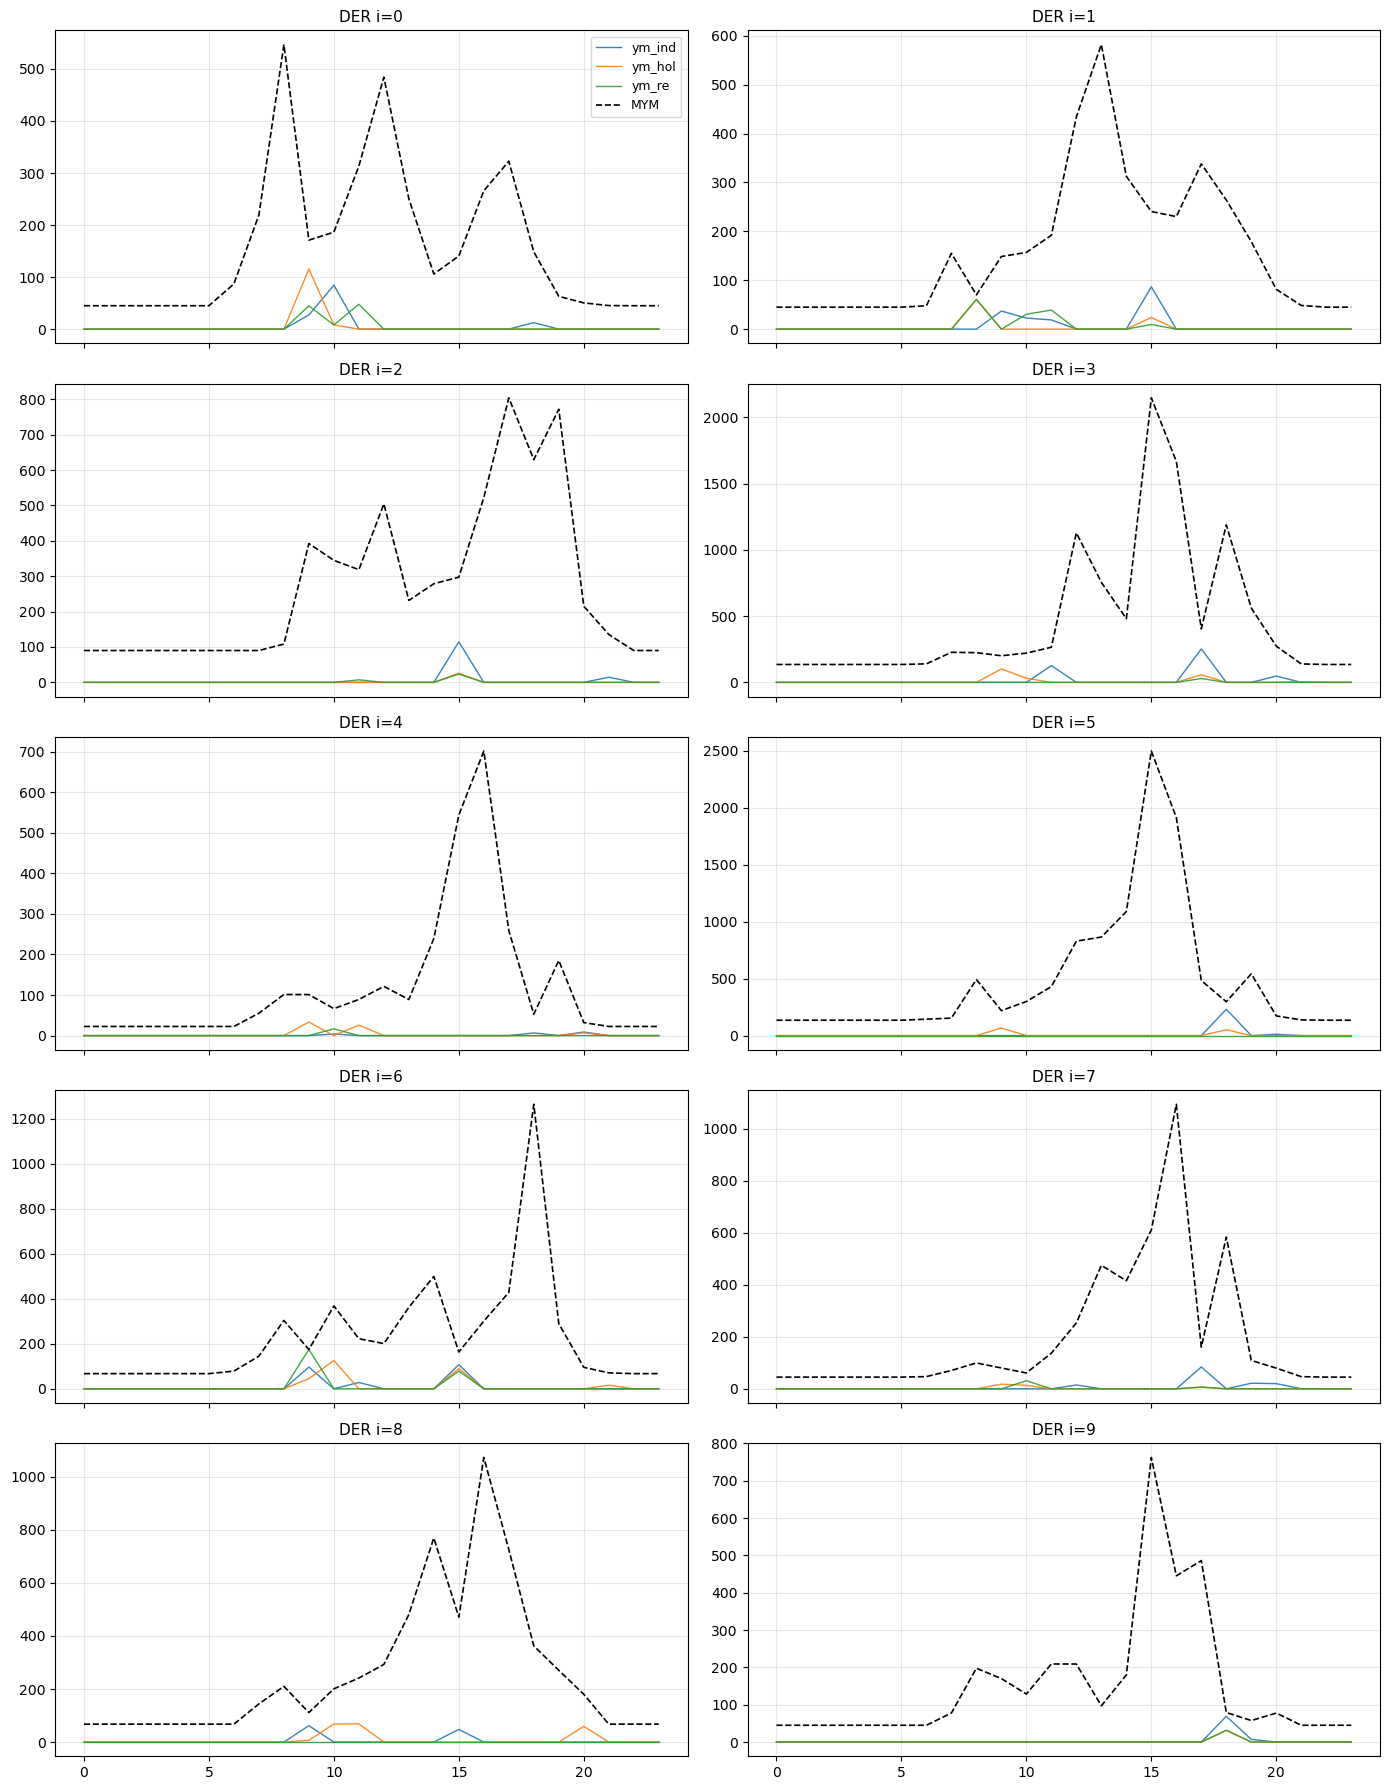

In [20]:
s=0
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)

for idx, i in enumerate(range(10)):
    ax = axes[idx]
    
    ax.plot(t_idx, ym_ind[i, :, s], linewidth=1, label='ym_ind', alpha=0.9)
    ax.plot(t_idx, ym_hol[i, :, s], linewidth=1, label='ym_hol', alpha=0.9)
    ax.plot(t_idx, ym_re[i, :, s], linewidth=1, label='ym_re', alpha=0.9)
    ax.plot(t_idx, MYM[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MYM')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


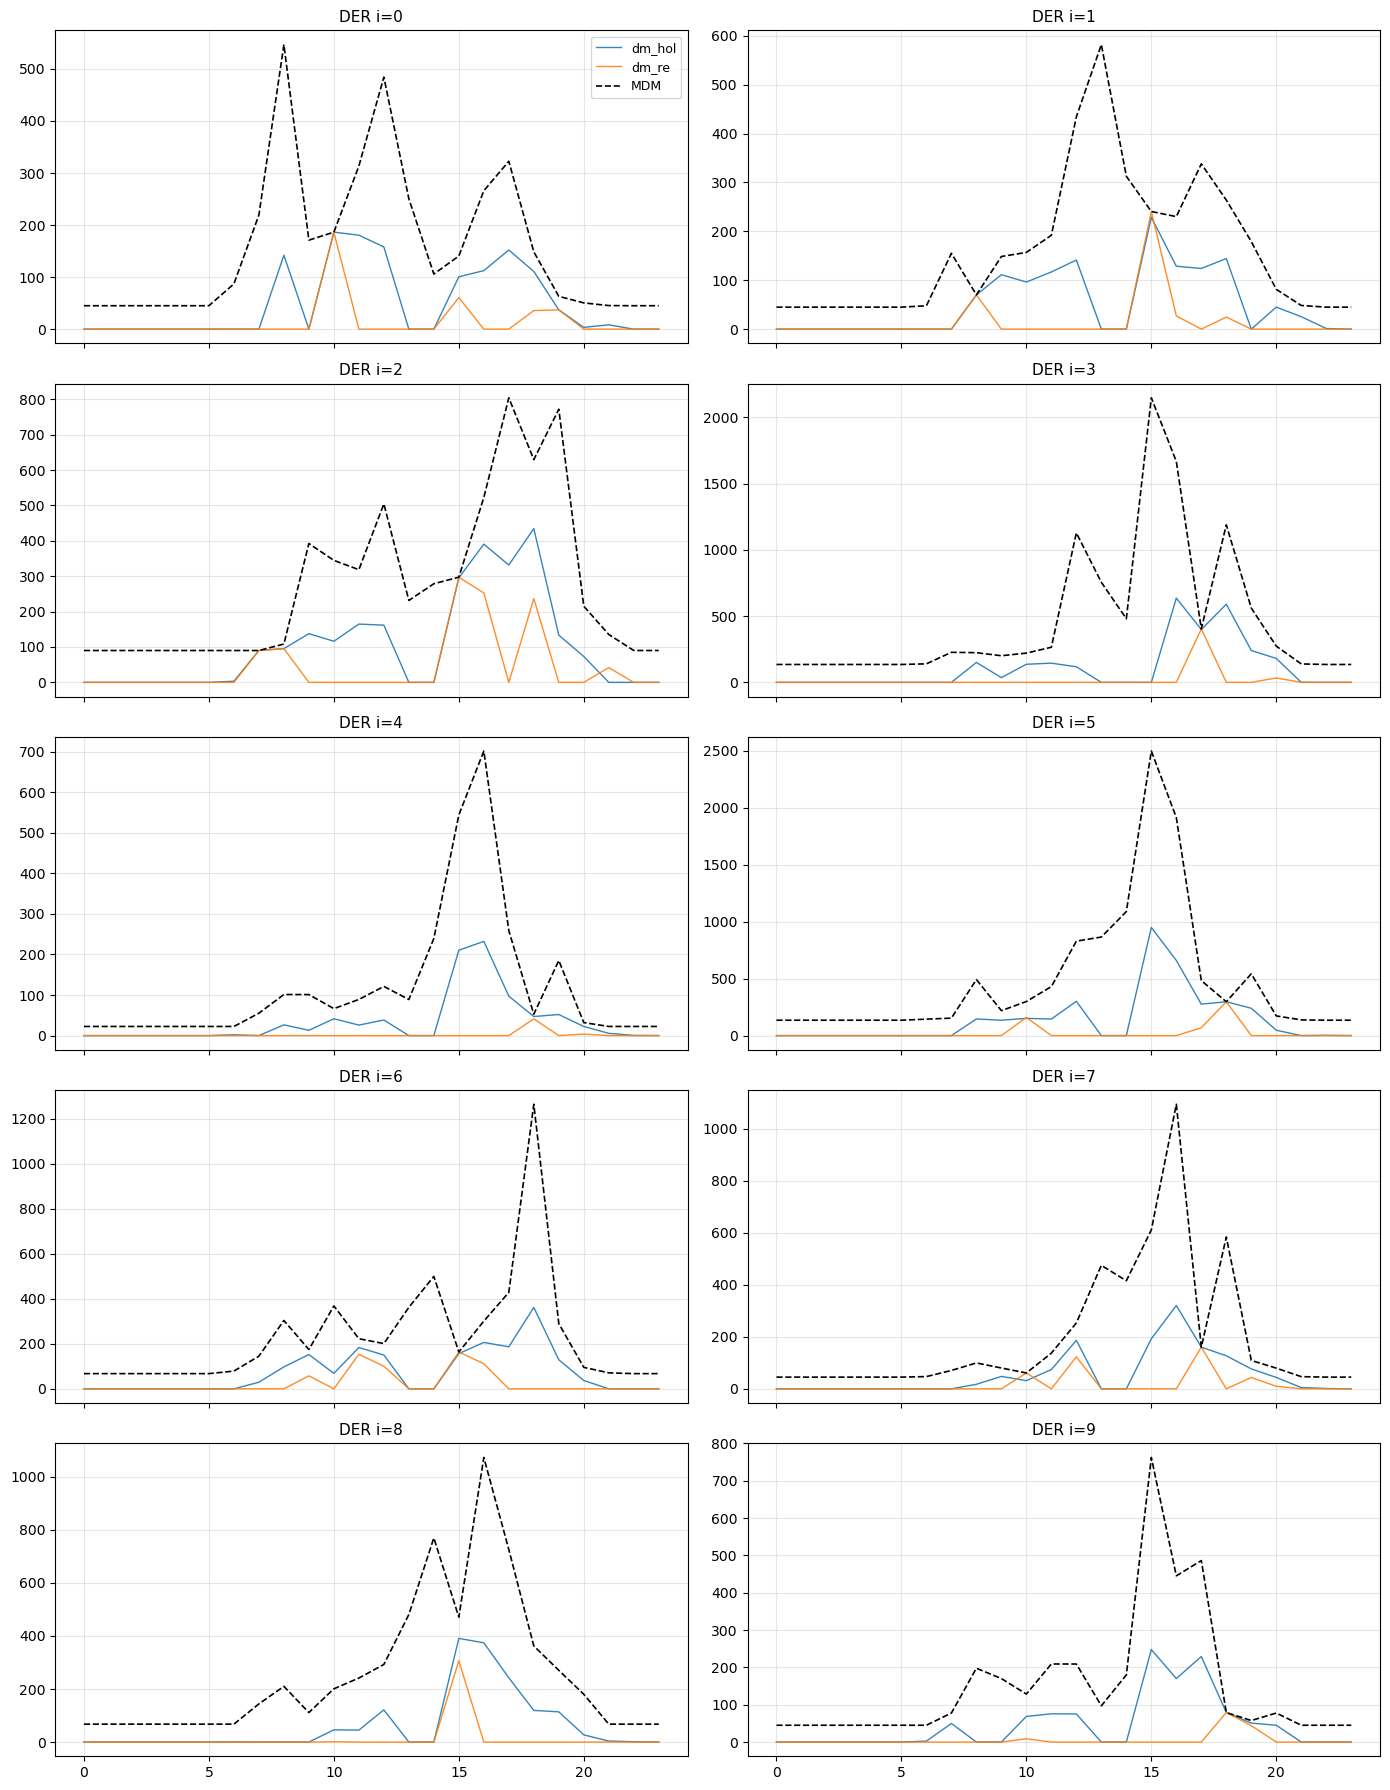

In [21]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)

for idx, i in enumerate(range(10)):
    ax = axes[idx]
    
    ax.plot(t_idx, dm_hol[i, :, s], linewidth=1, label='dm_hol', alpha=0.9)
    ax.plot(t_idx, dm_re[i, :, s], linewidth=1, label='dm_re', alpha=0.9)
    ax.plot(t_idx, MDM[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MDM')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


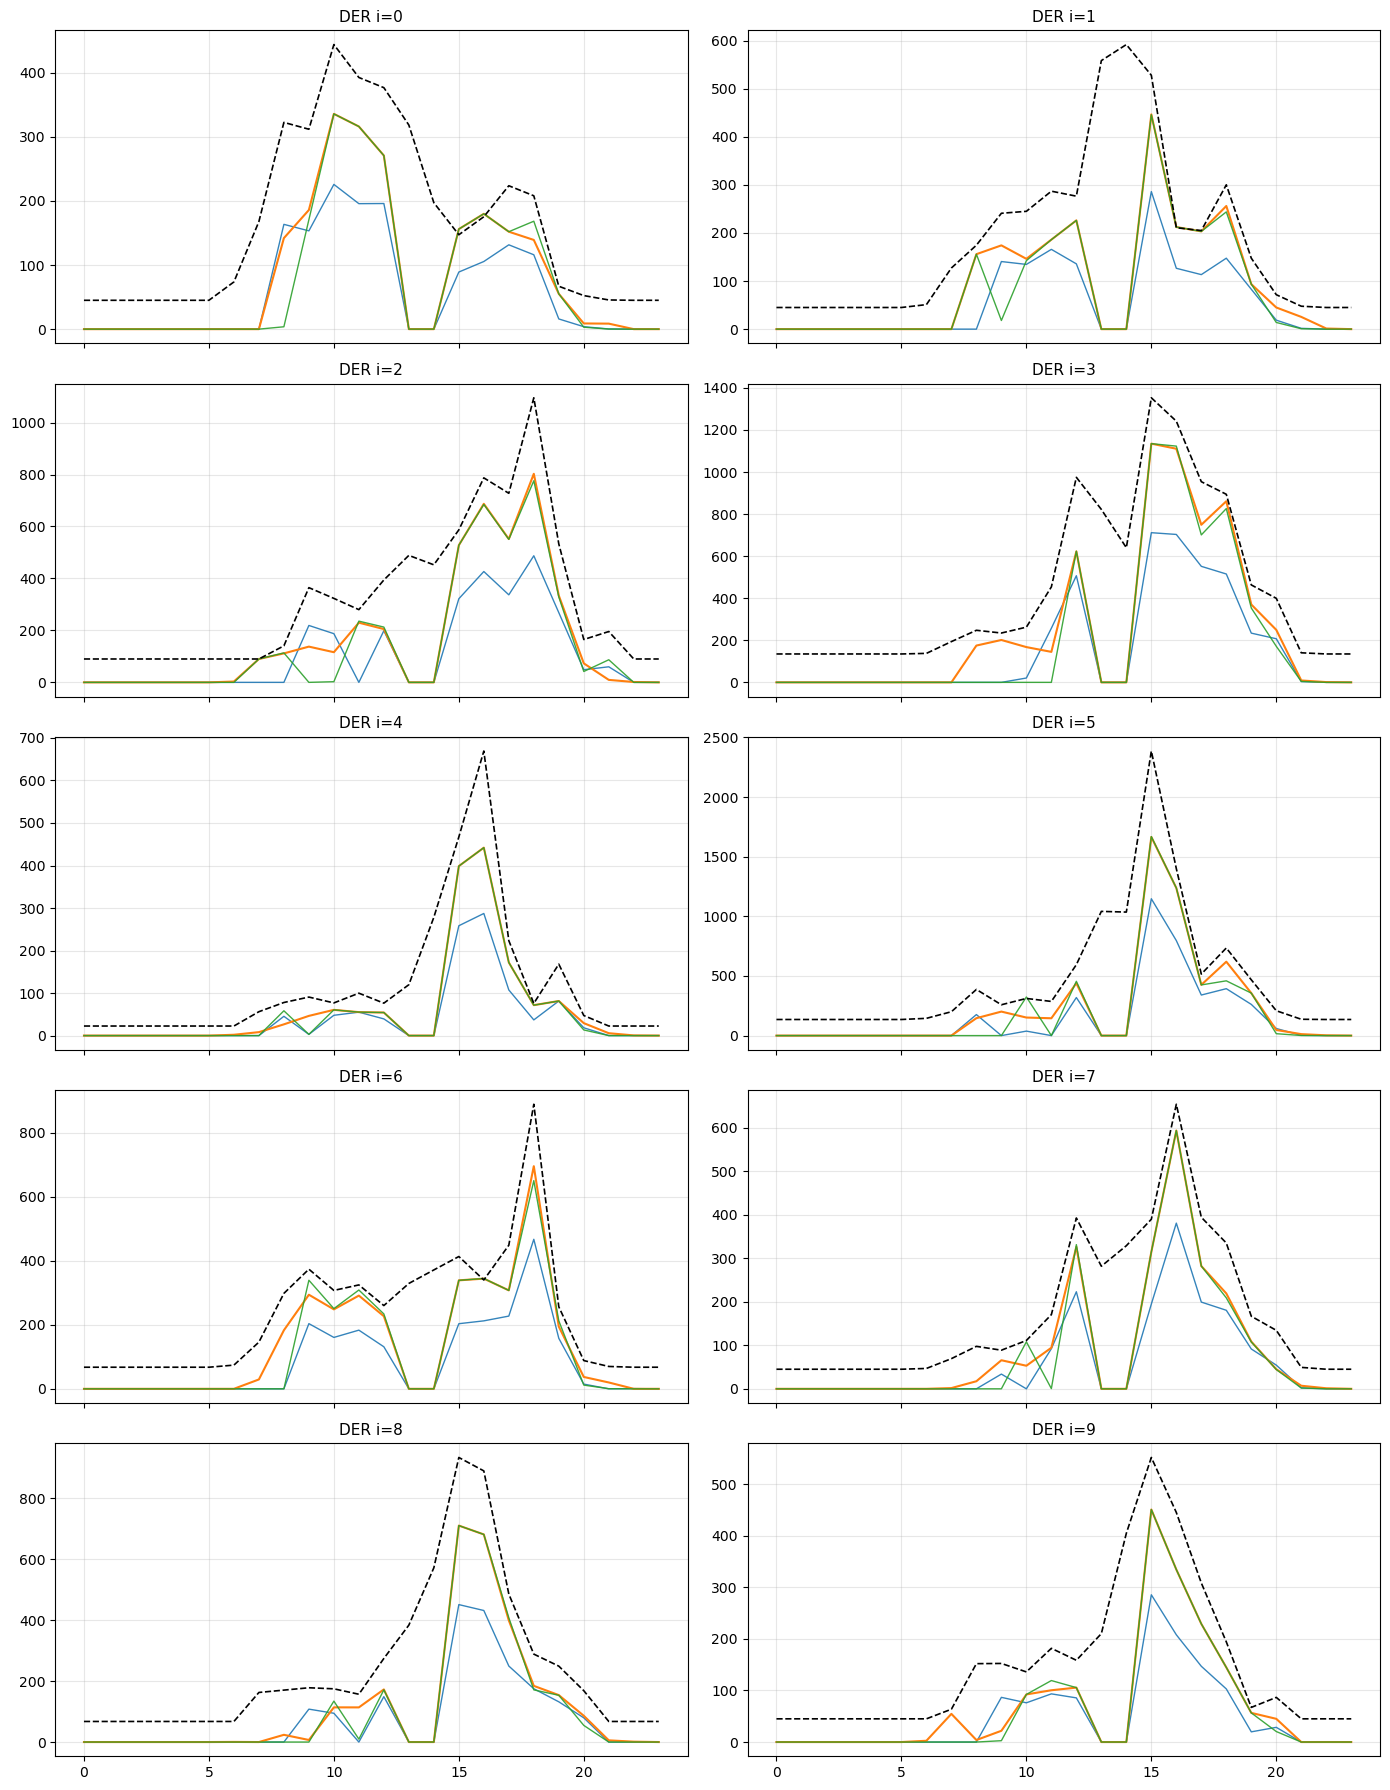

In [26]:
# === 시나리오 선택 ===
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)
R_avg = np.mean(R, axis=2)

for idx, i in enumerate(range(10)):
    ax = axes[idx]
    ax.plot(t_idx, x_ind[i, :], linewidth=1, label='x_ind', alpha=0.9)
    ax.plot(t_idx, x_hol[i, :], linewidth=1.5, label='x_hol', alpha=1)
    ax.plot(t_idx, x_re[i, :], linewidth=1, label='x_re', alpha=0.9)
    ax.plot(t_idx, 1*(R_avg[i, :] + INEFF * DRATE[i]), linestyle='--', color='black', linewidth=1.2, label='R_avg')

    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    # if idx == 0:
    #     ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


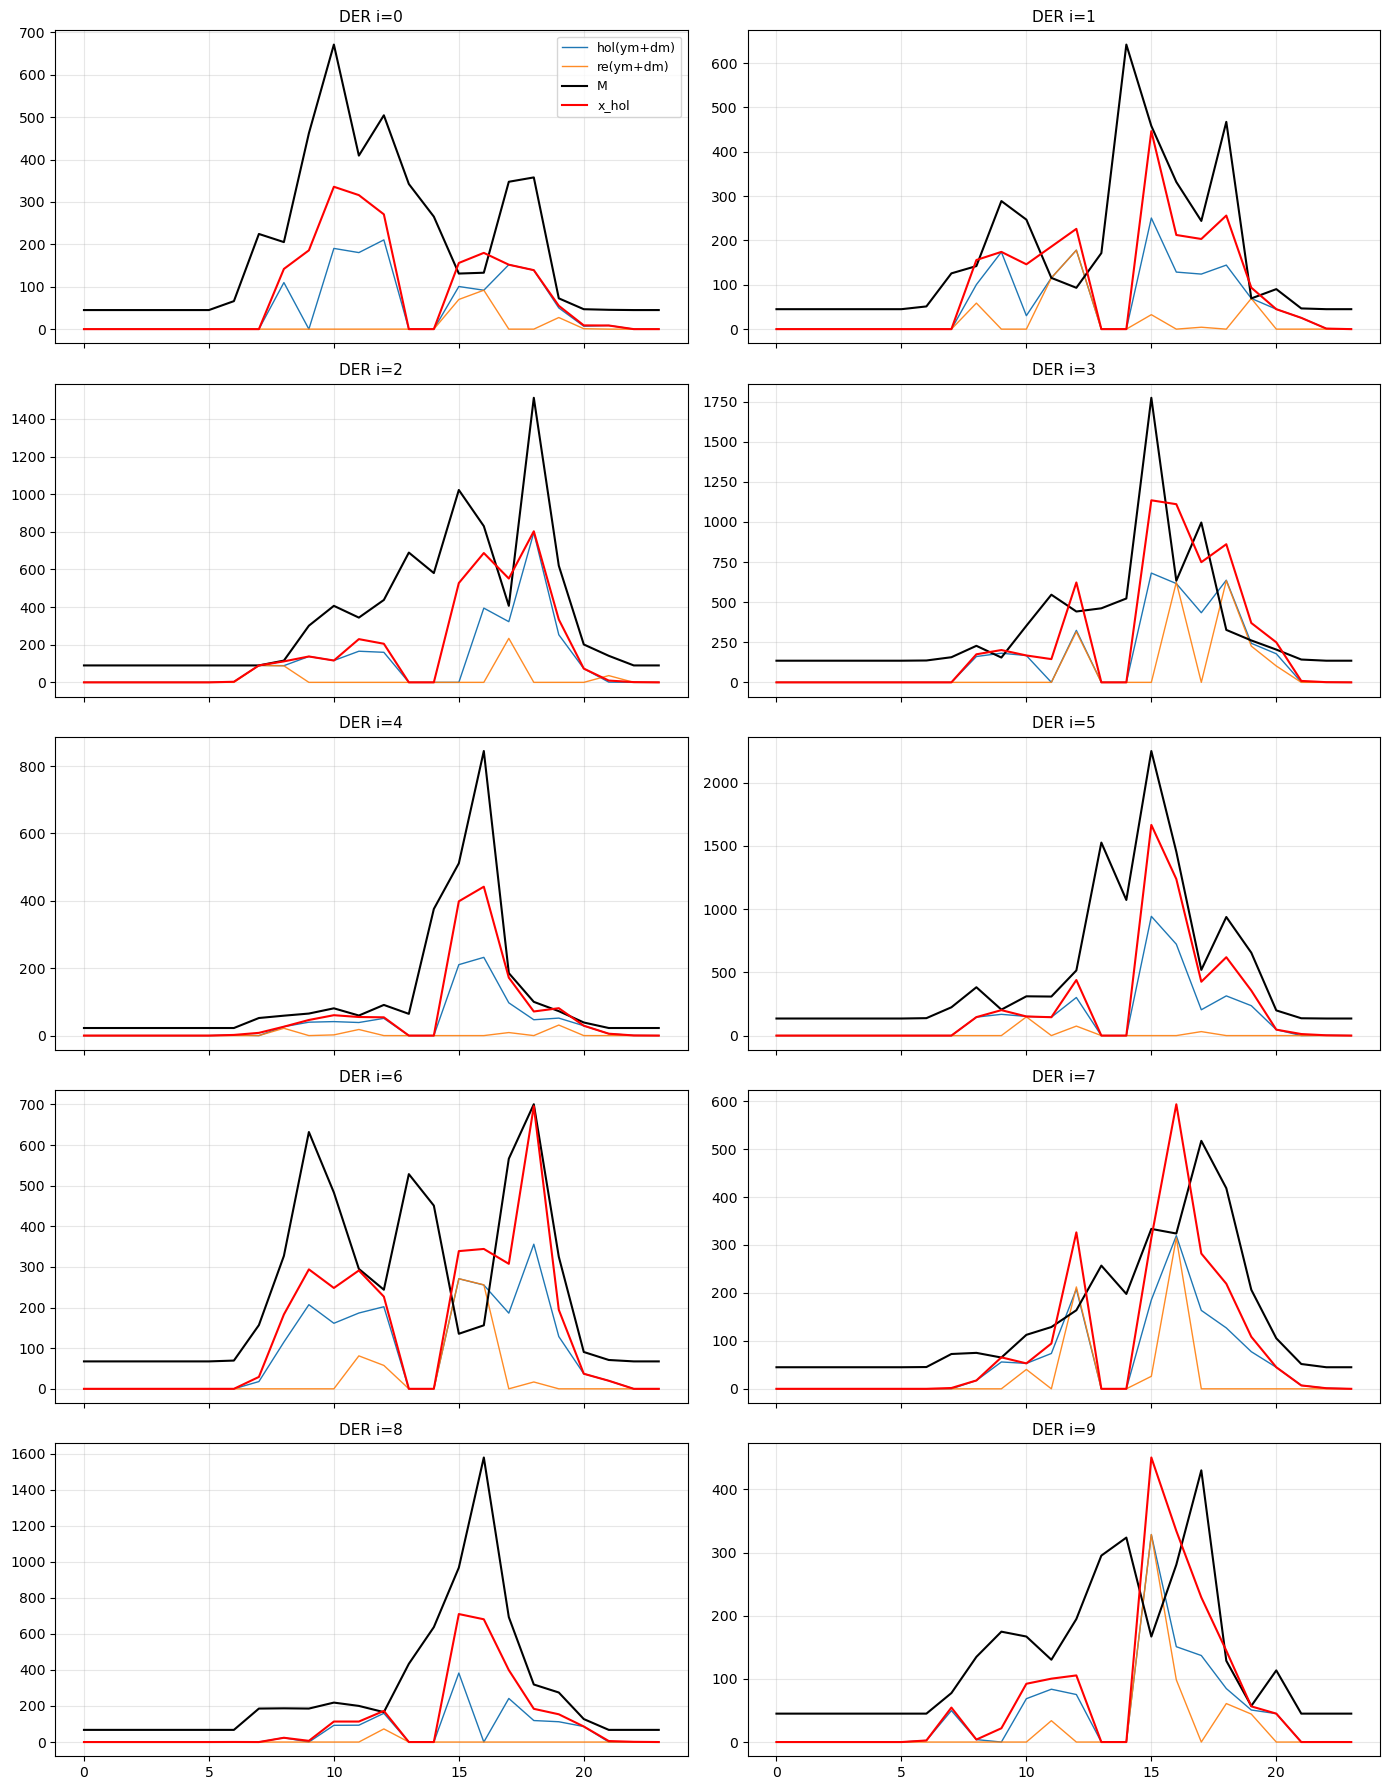

In [27]:
# === 시나리오 선택 ===
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)
R_avg = np.mean(R, axis=2)
s=6

for idx, i in enumerate(range(10)):
    ax = axes[idx]
    # ax.plot(t_idx, ym_ind[i, :, s], linewidth=1, label='ind(ym)', alpha=0.9)
    ax.plot(t_idx, ym_hol[i, :, s]+dm_hol[i, :, s], linewidth=1, label='hol(ym+dm)', alpha=1)
    ax.plot(t_idx, ym_re[i, :, s]+dm_re[i, :, s], linewidth=1, label='re(ym+dm)', alpha=0.9)
    ax.plot(t_idx, R[i, :, s] + INEFF * DRATE[i], color='black', linewidth=1.5, label='M')
    ax.plot(t_idx, x_hol[i, :], linewidth=1.5, label='x_hol', alpha=1, color='red')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()
t_idx = np.arange(T)
for idx, i in enumerate(range(10)):
    ax = axes[idx]
    ax.plot(t_idx, yp_ind[i, :, s], linewidth=1, label='yp_ind', alpha=0.9)
    ax.plot(t_idx, yp_hol[i, :, s], linewidth=1, label='yp_hol', alpha=0.9)
    ax.plot(t_idx, yp_re[i, :, s], linewidth=1, label='yp_re', alpha=0.9)
    ax.plot(t_idx, MYP[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MYP')
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
# axes = axes.flatten()
# t_idx = np.arange(T)
# for idx, i in enumerate(range(10)):
#     ax = axes[idx]
#     ax.plot(t_idx, dp_hol[i, :, s], linewidth=1, label='dp_hol', alpha=0.9)
#     ax.plot(t_idx, dp_re[i, :, s], linewidth=1, label='dp_re', alpha=0.9)
#     ax.plot(t_idx, MDP[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MDP')
#     ax.set_title(f"DER i={i}", fontsize=11)
#     ax.grid(True, alpha=0.3)
#     if idx == 0:
#         ax.legend(fontsize=9)
# plt.tight_layout()
# plt.show()


# fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
# axes = axes.flatten()
# t_idx = np.arange(T)
# for idx, i in enumerate(range(10)):
#     ax = axes[idx]
#     ax.plot(t_idx, zc_ind[i, :, s], linewidth=1, label='zc_ind', alpha=0.9)
#     ax.plot(t_idx, zc_hol[i, :, s], linewidth=1, label='zc_hol', alpha=0.9)
#     ax.plot(t_idx, zc_re[i, :, s], linewidth=1, label='zc_re', alpha=0.9)
#     ax.plot(t_idx, MZC[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MZC')
#     ax.set_title(f"DER i={i}", fontsize=11)
#     ax.grid(True, alpha=0.3)
#     if idx == 0:
#         ax.legend(fontsize=9)
# plt.tight_layout()
# plt.show()


# fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
# axes = axes.flatten()
# t_idx = np.arange(T)
# for idx, i in enumerate(range(10)):
#     ax = axes[idx]
#     ax.plot(t_idx, zd_ind[i, :, s], linewidth=1, label='zd_ind', alpha=0.9)
#     ax.plot(t_idx, zd_hol[i, :, s], linewidth=1.5, label='zd_hol', alpha=1)
#     ax.plot(t_idx, zd_re[i, :, s], linewidth=1, label='zd_re', alpha=0.9)
#     ax.plot(t_idx, MZD[i, :, s], linestyle='--', color='black', linewidth=1.2, label='MZD')
#     ax.set_title(f"DER i={i}", fontsize=11)
#     ax.grid(True, alpha=0.3)
#     if idx == 0:
#         ax.legend(fontsize=9)
# plt.tight_layout()
# plt.show()
